# Bank Reinforcement Learning — End-to-End Next Best Action

## Business Case

A bank wants to decide **which action to take next for a customer**.

Possible actions:

- No Offer
- Savings Offer
- Credit Card Offer
- Personal Loan Offer
- Investment Offer

The objective is not simply to predict:

> "Will the customer buy?"

Instead, Reinforcement Learning asks:

> **"Given the current customer state, which action should the bank take to maximize long-term reward?"**

This notebook demonstrates a simplified **contextual bandit / Reinforcement Learning** workflow using synthetic banking data.

## 1. Reinforcement Learning Concept

The basic RL loop is:

```text
Environment
    ↓
State
    ↓
Agent
    ↓
Action
    ↓
Reward
    ↓
New State
    ↓
Agent learns
```

For banking:

```text
Customer State
      ↓
Decision Agent
      ↓
Offer / No Offer
      ↓
Customer Response
      ↓
Reward
      ↓
Learning
```

## 2. Important Terminology

### State

The current situation.

Example:

```text
Income = High
Balance = High
Digital Engagement = 85
Tenure = Loyal
Recent Activity = High
```

### Action

What the agent can do.

```text
No Offer
Savings
Credit Card
Personal Loan
Investment
```

### Reward

Feedback from the environment.

For example:

```text
Customer accepts offer → positive reward
Customer ignores offer → low reward
Customer rejects / campaign causes negative response → negative reward
```

### Policy

The strategy used by the agent to select an action.

## 3. Why RL Instead of Ordinary Classification?

Classification:

```text
Customer → Will buy credit card?
```

RL / contextual bandit:

```text
Customer
   ↓
Which action should we take?
   ↓
Credit Card / Savings / Loan / Investment / No Offer
   ↓
Observe reward
   ↓
Improve future decisions
```

RL becomes particularly interesting when actions influence future customer states and the objective is long-term rather than a single prediction.

## 4. Banking Use Cases

Potential applications:

- Next Best Action
- Personalized campaign optimization
- Offer selection
- Digital engagement optimization
- Branch service routing
- Customer retention actions
- Dynamic communication timing
- Resource allocation

For lending, RL should **not bypass credit policy or underwriting controls**. Eligibility and risk policy remain hard constraints.

## 5. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling and Q-table maths, and Matplotlib/Seaborn for visualisation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid")
np.random.seed(42)

pd.set_option("display.max_columns",100)
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


## 6. Load Synthetic Data

The three synthetic tables — customer states, historical interactions and the action catalogue — are loaded. Together they define the environment in which the next-best-action agent learns.


In [2]:
customers=pd.read_csv("customer_states_sample.csv")
actions=pd.read_csv("actions_sample.csv")
history=pd.read_csv("historical_interactions_sample.csv")

print("Customers:",customers.shape)
print("Actions:",actions.shape)
print("History:",history.shape)

display(customers.head())
display(actions)
display(history.head())

Customers: (5000, 6)
Actions: (5, 2)
History: (5000, 4)


,Customer_ID,Income_Band,Digital_Engagement,Balance_Band,Tenure_Band,Recent_Activity
0,C00001,Medium,47,Medium,Established,Medium
1,C00002,Medium,37,Medium,New,High
2,C00003,High,62,Low,New,Low
3,C00004,Medium,73,Medium,Loyal,Medium
4,C00005,Low,41,Medium,Established,Medium


,Action_ID,Action
0,0,No Offer
1,1,Savings Offer
2,2,Credit Card Offer
3,3,Personal Loan Offer
4,4,Investment Offer


,Customer_ID,Action_ID,Action,Reward
0,C00001,4,Investment Offer,0.457298
1,C00002,2,Credit Card Offer,0.710248
2,C00003,3,Personal Loan Offer,0.525398
3,C00004,3,Personal Loan Offer,0.481441
4,C00005,1,Savings Offer,0.263210


## 7. Explore Historical Rewards

Average historical reward per action is computed to see which actions paid off in the past and how much a naive, always-the-same-action policy would earn — the benchmark the learned policy must beat.


In [3]:
reward_summary=(
    history.groupby("Action")
    .agg(
        Observations=("Reward","size"),
        Average_Reward=("Reward","mean"),
        Reward_Std=("Reward","std")
    )
    .sort_values("Average_Reward",ascending=False)
)

display(reward_summary.round(3))

,Observations,Average_Reward,Reward_Std
Action,,,
Investment Offer,993,0.625,0.348
Savings Offer,1001,0.515,0.281
Credit Card Offer,1019,0.453,0.283
Personal Loan Offer,1043,0.452,0.314
No Offer,944,0.044,0.245


Saved: output/7-explore-historical-rewards.png


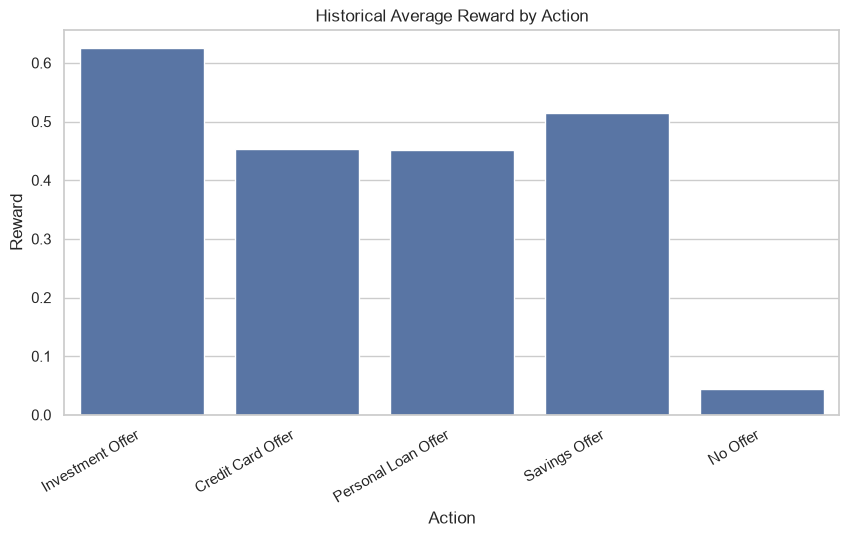

In [4]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=history,
    x="Action",
    y="Reward",
    errorbar=None
)
plt.xticks(rotation=30,ha="right")
plt.title("Historical Average Reward by Action")
save_plot("7-explore-historical-rewards.png")
plt.show()

## 8. Contextual Bandit

This project starts with a **contextual bandit**.

A contextual bandit is closely related to RL but simplifies the environment:

```text
Current State
     ↓
Choose Action
     ↓
Observe Reward
```

There is no explicit multi-step state transition in the basic example.

This makes it a useful starting point for understanding RL in recommendation and marketing problems.

## 9. State Representation

Categorical customer attributes:

- Income Band
- Balance Band
- Tenure Band
- Recent Activity

Numerical:

- Digital Engagement

We encode categorical variables so an algorithm can use them.

In [5]:
feature_cols=[
    "Income_Band",
    "Digital_Engagement",
    "Balance_Band",
    "Tenure_Band",
    "Recent_Activity"
]

X=customers[feature_cols].copy()

preprocessor=ColumnTransformer([
    ("cat",OneHotEncoder(handle_unknown="ignore"),
     ["Income_Band","Balance_Band","Tenure_Band","Recent_Activity"]),
    ("num","passthrough",["Digital_Engagement"])
])

X_encoded=preprocessor.fit_transform(X)

print("Encoded state dimensions:",X_encoded.shape[1])

Encoded state dimensions: 13


## 10. Reward Model

A simple way to learn from historical data is to estimate:

```text
Expected Reward(state, action)
```

Then choose:

```text
action = argmax Expected Reward
```

This is a simplified **model-based contextual decision policy**.

It is useful as a baseline before implementing a full RL environment.

In [6]:
# Create state-action training data
train_df=history.merge(customers,on="Customer_ID")

X_state=train_df[feature_cols]
X_action=pd.get_dummies(train_df["Action_ID"],prefix="Action")

model_input=pd.concat(
    [X_state.reset_index(drop=True),X_action.reset_index(drop=True)],
    axis=1
)

# Use a preprocessing pipeline for state + action
state_action_features=[
    "Income_Band","Digital_Engagement",
    "Balance_Band","Tenure_Band",
    "Recent_Activity","Action_ID"
]

X_sa=train_df[state_action_features].copy()
y=train_df["Reward"].values

sa_preprocessor=ColumnTransformer([
    ("cat",OneHotEncoder(handle_unknown="ignore"),
     ["Income_Band","Balance_Band","Tenure_Band","Recent_Activity","Action_ID"]),
    ("num","passthrough",["Digital_Engagement"])
])

reward_model=Pipeline([
    ("prep",sa_preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

# Convert continuous reward into positive/negative response for a simple baseline
y_binary=(y>np.median(y)).astype(int)

reward_model.fit(X_sa,y_binary)
print("Baseline reward-response model trained.")

Baseline reward-response model trained.


## 11. Why This Is Only a Baseline

The simple classifier above predicts whether an action's historical reward is relatively high.

A true RL system would model:

```text
State → Action → Reward → Next State
```

and optimize cumulative future reward.

For this notebook, we progressively move from:

```text
Contextual Decision
```

to:

```text
Q-Learning
```

to illustrate the RL mechanism.

## 12. Q-Learning

Q-learning estimates:

```text
Q(state, action)
```

which represents the expected future reward of taking an action from a state.

The update is:

```text
Q(s,a) ← Q(s,a)
       + α [r + γ max Q(s',a') - Q(s,a)]
```

Where:

- `α` = learning rate
- `γ` = discount factor
- `r` = reward
- `s'` = next state

## 13. Create a Discrete Banking Environment

To make Q-learning easy to understand, we discretize the customer state.

Example:

```text
Digital Engagement
0–39   → Low
40–69  → Medium
70–100 → High
```

The state becomes a combination of customer characteristics.

In [7]:
def digitize_customer(row):
    digital="Low" if row.Digital_Engagement<40 else (
        "Medium" if row.Digital_Engagement<70 else "High"
    )
    return (
        row.Income_Band,
        digital,
        row.Balance_Band,
        row.Tenure_Band,
        row.Recent_Activity
    )

customers["State"]=customers.apply(digitize_customer,axis=1)
state_list=customers["State"].unique().tolist()
state_to_id={s:i for i,s in enumerate(state_list)}

customers["State_ID"]=customers["State"].map(state_to_id)

print("Number of states:",len(state_list))
display(customers[["Customer_ID","State","State_ID"]].head())

Number of states: 243


,Customer_ID,State,State_ID
0,C00001,"(Medium, Medium, Medium, Established, Medium)",0
1,C00002,"(Medium, Low, Medium, New, High)",1
2,C00003,"(High, Medium, Low, New, Low)",2
3,C00004,"(Medium, High, Medium, Loyal, Medium)",3
4,C00005,"(Low, Medium, Medium, Established, Medium)",4


## 14. Build Q-Table

The Q-table contains:

```text
Rows    = states
Columns = actions
Values  = expected reward
```

In [8]:
n_states=len(state_list)
n_actions=len(actions)

Q=np.zeros((n_states,n_actions))

print("Q-table shape:",Q.shape)
display(pd.DataFrame(Q,columns=actions["Action"]))

Q-table shape: (243, 5)


Action,No Offer,Savings Offer,Credit Card Offer,Personal Loan Offer,Investment Offer
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
238,0.0,0.0,0.0,0.0,0.0
239,0.0,0.0,0.0,0.0,0.0
240,0.0,0.0,0.0,0.0,0.0
241,0.0,0.0,0.0,0.0,0.0


## 15. Epsilon-Greedy Policy

The agent needs to balance:

### Exploration

Try actions to learn their rewards.

### Exploitation

Choose the action currently believed to be best.

Epsilon-greedy:

```text
with probability ε → random action
otherwise          → best known action
```

We gradually reduce epsilon during training.

In [9]:
def choose_action(state_id,Q,epsilon):
    if np.random.random()<epsilon:
        return np.random.randint(Q.shape[1])
    return int(np.argmax(Q[state_id]))

def simulate_reward(customer_row,action_id):
    income={"Low":0,"Medium":1,"High":2}[customer_row.Income_Band]
    balance={"Low":0,"Medium":1,"High":2}[customer_row.Balance_Band]
    digital=customer_row.Digital_Engagement/100
    tenure={"New":0,"Established":.5,"Loyal":1}[customer_row.Tenure_Band]
    activity={"Low":0,"Medium":.5,"High":1}[customer_row.Recent_Activity]

    base={
        0:.05,
        1:.25+.18*balance+.10*digital+.10*tenure,
        2:.15+.15*income+.18*digital+.12*activity,
        3:.05+.25*income+.18*activity+.10*balance,
        4:.10+.25*balance+.20*income+.20*digital
    }[action_id]

    return base+np.random.normal(0,.10)

## 16. Train Q-Learning Agent

For each episode:

1. Select a customer state.
2. Choose an action.
3. Observe reward.
4. Update Q-value.
5. Repeat.

Because this simplified environment has no explicit transition, the Q update reduces to a contextual reward-learning problem.

In [10]:
alpha=.10
gamma=.90
episodes=30000

episode_rewards=[]

for episode in range(episodes):
    row=customers.sample(1).iloc[0]
    s=int(row.State_ID)

    epsilon=max(.05,1-(episode/episodes))

    a=choose_action(s,Q,epsilon)
    reward=simulate_reward(row,a)

    # Simplified one-step contextual bandit update
    Q[s,a]=Q[s,a]+alpha*(reward-Q[s,a])

    episode_rewards.append(reward)

print("Training completed.")

Training completed.


## 17. Q-Table After Training

The learned Q-table — the expected long-term value of each action in each customer state — is displayed. Higher Q-values show which action the agent has learned to prefer for that state.


In [11]:
q_table=pd.DataFrame(Q,columns=actions["Action"])
q_table.index.name="State_ID"

display(q_table.round(3))

Action,No Offer,Savings Offer,Credit Card Offer,Personal Loan Offer,Investment Offer
State_ID,,,,,
0,0.090,0.561,0.429,0.486,0.641
1,0.042,0.376,0.389,0.590,0.458
2,0.024,0.110,0.517,0.195,0.256
3,0.034,0.523,0.451,0.383,0.756
4,0.052,0.558,0.305,0.227,0.466
...,...,...,...,...,...
238,0.018,0.062,0.194,0.083,0.839
239,0.000,0.557,0.100,0.165,0.000
240,0.008,0.047,0.218,0.063,0.606


Saved: output/17-q-table-after-training.png


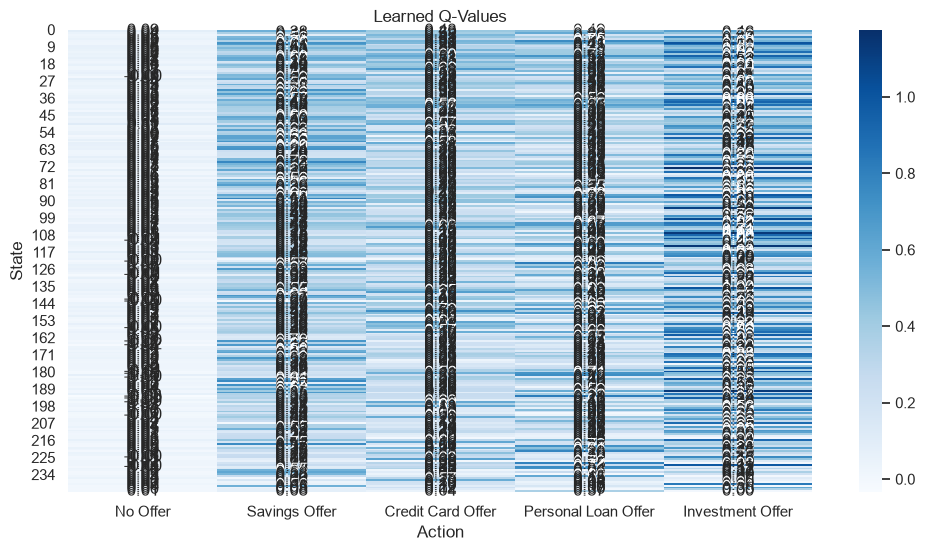

In [12]:
plt.figure(figsize=(12,6))
sns.heatmap(q_table,annot=True,fmt=".2f",cmap="Blues")
plt.title("Learned Q-Values")
plt.xlabel("Action")
plt.ylabel("State")
save_plot("17-q-table-after-training.png")
plt.show()

## 18. Learned Policy

The policy selects the action with the highest Q-value:

```text
π(state) = argmax Q(state, action)
```

In [13]:
policy=q_table.idxmax(axis=1).reset_index()
policy.columns=["State_ID","Recommended_Action"]

policy=policy.merge(
    customers[["State_ID","State"]].drop_duplicates(),
    on="State_ID",
    how="left"
)

display(policy)

,State_ID,Recommended_Action,State
0,0,Investment Offer,"(Medium, Medium, Medium, Established, Medium)"
1,1,Personal Loan Offer,"(Medium, Low, Medium, New, High)"
2,2,Credit Card Offer,"(High, Medium, Low, New, Low)"
3,3,Investment Offer,"(Medium, High, Medium, Loyal, Medium)"
4,4,Savings Offer,"(Low, Medium, Medium, Established, Medium)"
...,...,...,...
238,238,Investment Offer,"(High, Medium, High, New, High)"
239,239,Savings Offer,"(High, Medium, High, Loyal, High)"
240,240,Investment Offer,"(Low, Medium, High, New, High)"
241,241,Investment Offer,"(High, Low, Low, Loyal, High)"


## 19. Next Best Action Function

A wrapper maps any customer row to its state and returns the action with the highest Q-value. This function is the deployable next-best-action recommendation the business would call at decision time.


In [14]:
def recommend_action(customer_row,Q=Q):
    state=digitize_customer(customer_row)
    sid=state_to_id[state]

    q_values=Q[sid]
    action_id=int(np.argmax(q_values))

    return {
        "State":state,
        "Recommended_Action":actions.loc[action_id,"Action"],
        "Q_Value":q_values[action_id],
        "All_Action_Scores":dict(zip(actions["Action"],q_values))
    }

example=customers.iloc[0]
display(recommend_action(example))

{'State': ('Medium', 'Medium', 'Medium', 'Established', 'Medium'),
 'Recommended_Action': 'Investment Offer',
 'Q_Value': np.float64(0.6405473709610802),
 'All_Action_Scores': {'No Offer': np.float64(0.08977825730372313),
  'Savings Offer': np.float64(0.5611001122908322),
  'Credit Card Offer': np.float64(0.4286626915118139),
  'Personal Loan Offer': np.float64(0.48563836476647526),
  'Investment Offer': np.float64(0.6405473709610802)}}

## 20. Exploration vs Exploitation

During training:

```text
Early training
ε high
↓
Explore many actions

Later training
ε low
↓
Exploit learned policy
```

This is one of the central ideas of reinforcement learning.

Saved: output/20-exploration-vs-exploitation.png


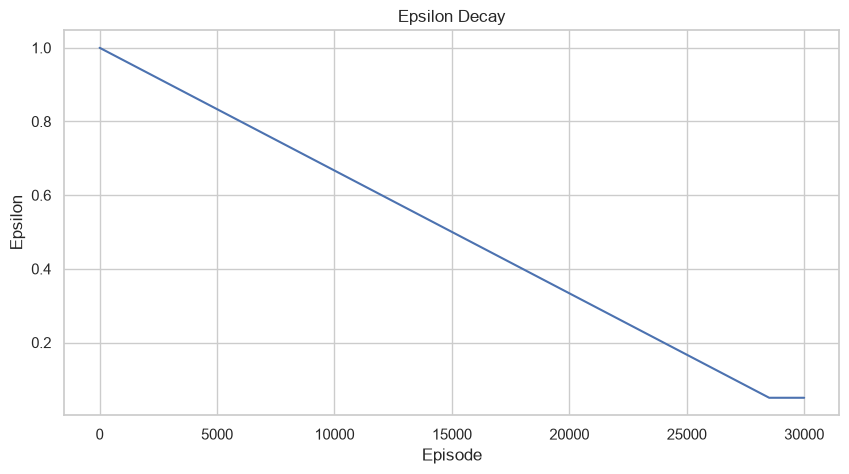

In [15]:
epsilons=np.maximum(.05,1-np.arange(episodes)/episodes)

plt.figure(figsize=(10,5))
plt.plot(epsilons)
plt.title("Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
save_plot("20-exploration-vs-exploitation.png")
plt.show()

## 21. Evaluate the Learned Policy

We compare:

### Random policy

Choose an action randomly.

### Learned policy

Choose the highest-Q action.

The comparison is performed using the same simulated environment.

In [16]:
def evaluate_policy(policy_fn,n=3000):
    rewards=[]
    for _ in range(n):
        row=customers.sample(1).iloc[0]
        a=policy_fn(row)
        rewards.append(simulate_reward(row,a))
    return np.mean(rewards),np.std(rewards)

random_mean,random_std=evaluate_policy(
    lambda row: np.random.randint(n_actions)
)

learned_mean,learned_std=evaluate_policy(
    lambda row: int(np.argmax(Q[state_to_id[digitize_customer(row)]]))
)

comparison=pd.DataFrame({
    "Policy":["Random","Learned Q-Policy"],
    "Mean_Reward":[random_mean,learned_mean],
    "Std_Reward":[random_std,learned_std]
})

display(comparison.round(3))

,Policy,Mean_Reward,Std_Reward
0,Random,0.415,0.265
1,Learned Q-Policy,0.623,0.211


## 22. Important Offline Evaluation Warning

Real banking systems usually have **historical observational data**.

The bank only observes the reward for the action that was actually taken.

Example:

```text
Customer A → Credit Card Offer → accepted
```

We do not directly know:

```text
What would have happened if Customer A
had received an Investment Offer?
```

This is a major challenge called the **counterfactual problem**.

Offline RL therefore requires careful evaluation methods such as:
- inverse propensity scoring,
- doubly robust estimation,
- off-policy evaluation.

## 23. Policy Constraints

A production banking agent should never be allowed to freely choose every possible action.

Use hard constraints:

```text
Customer
   ↓
Eligibility
   ↓
Risk / Compliance Rules
   ↓
Allowed Actions
   ↓
RL Policy
   ↓
Best Allowed Action
```

For example, a loan recommendation cannot override credit policy.

## 24. Reward Design

Reward design is critical.

Possible business rewards:

```text
Application completed       +10
Product activated           +20
Customer engagement          +3
Offer clicked                +1
Ignored offer                0
Customer opt-out             -5
Complaint                    -20
```

Poor reward design can cause undesirable behavior.

For example, optimizing only short-term conversion could encourage excessive offers and damage customer experience.

## 25. Long-Term RL

The simplified notebook uses one-step rewards.

A full RL environment could include:

```text
Day 1
Customer State
    ↓
Offer
    ↓
Response
    ↓
Day 2 State
    ↓
Offer
    ↓
Response
    ↓
...
```

Then the agent can optimize:

```text
Cumulative Discounted Reward
```

rather than only the immediate response.

## 26. Production Architecture

```text
Customer Data
     ↓
Feature Store
     ↓
Current Customer State
     ↓
Eligibility / Compliance
     ↓
RL / Contextual Bandit Agent
     ↓
Next Best Action
     ↓
CRM / Mobile / Branch
     ↓
Customer Response
     ↓
Reward
     ↓
Experience / Event Store
     ↓
Model Training
     ↓
Policy Update
```

A production system should also include monitoring, audit logs, model governance, and safe fallback policies.

## 27. Monitoring

Monitor:

### Model
- average reward
- action distribution
- exploration rate
- policy stability

### Business
- conversion
- revenue
- customer engagement
- complaint rate

### Customer
- opt-out
- campaign fatigue
- customer experience

### Risk / Governance
- policy violations
- prohibited actions
- unusual action concentration
- explainability
- auditability

## 28. Common RL Mistakes

1. Treating RL as ordinary classification.
2. Designing rewards poorly.
3. Ignoring exploration cost.
4. Using observational data without counterfactual evaluation.
5. Allowing the agent to bypass business rules.
6. Optimizing short-term conversion only.
7. Ignoring customer experience.
8. Deploying without safe fallback.
9. Not monitoring policy drift.
10. Using a complex RL algorithm before establishing a strong baseline.

## 29. Recommended Learning Path

For banking analytics, a practical progression is:

```text
1. Rule-Based Next Best Action
          ↓
2. Supervised Response Model
          ↓
3. Contextual Bandit
          ↓
4. Offline Policy Evaluation
          ↓
5. Q-Learning
          ↓
6. Deep Q-Network
          ↓
7. Policy Gradient / Actor-Critic
          ↓
8. Production RL
```

This progression is generally easier to validate than jumping directly to Deep RL.

# Final Executive Summary

## Business Problem

Choose the next best action for a customer.

## RL Framework

```text
Customer State
      ↓
     Agent
      ↓
    Action
      ↓
Customer Response
      ↓
    Reward
      ↓
 Agent Learns
```

## Project Techniques

- Contextual decision making
- State representation
- Action space
- Reward design
- Epsilon-greedy exploration
- Q-table
- Q-learning
- Policy generation
- Policy evaluation
- Counterfactual/off-policy evaluation concepts
- Business constraints
- Production architecture

### Key takeaway

> **Reinforcement Learning is about learning which actions to take based on feedback, with the objective of maximizing reward over time.**

For banking, the strongest use cases are typically **Next Best Action, personalization, campaign optimization, and sequential customer engagement**, provided that policy, risk, compliance, and customer-protection constraints remain outside and above the agent.

## 30. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [17]:
q_table.to_csv(OUTPUT_DIR / "q_table.csv", index=False)
print("Saved:", OUTPUT_DIR / "q_table.csv")
policy.to_csv(OUTPUT_DIR / "learned_policy.csv", index=False)
print("Saved:", OUTPUT_DIR / "learned_policy.csv")
reward_summary.to_csv(OUTPUT_DIR / "historical_rewards_by_action.csv", index=False)
print("Saved:", OUTPUT_DIR / "historical_rewards_by_action.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/q_table.csv
Saved: output/learned_policy.csv
Saved: output/historical_rewards_by_action.csv
  output/17-q-table-after-training.png
  output/20-exploration-vs-exploitation.png
  output/7-explore-historical-rewards.png
  output/historical_rewards_by_action.csv
  output/learned_policy.csv
  output/q_table.csv
